In [10]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity, mean_squared_error

1. Load grayscale image

In [11]:
gray_image = cv2.imread("sar_1_gray.jpg", cv2.IMREAD_GRAYSCALE)
gray_image.shape

(400, 600)

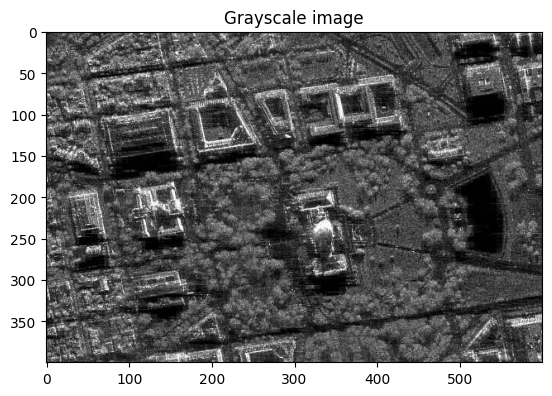

In [12]:
plt.imshow(gray_image, cmap="gray")
plt.title("Grayscale image")
plt.show()

2. Histogram

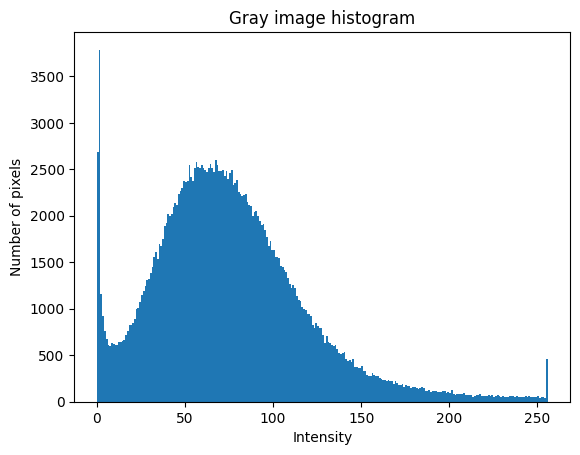

In [13]:
plt.hist(gray_image.ravel(), bins=256, range=(0, 256))
plt.title("Gray image histogram")
plt.xlabel("Intensity")
plt.ylabel("Number of pixels")
plt.show()

3. Gamma correction

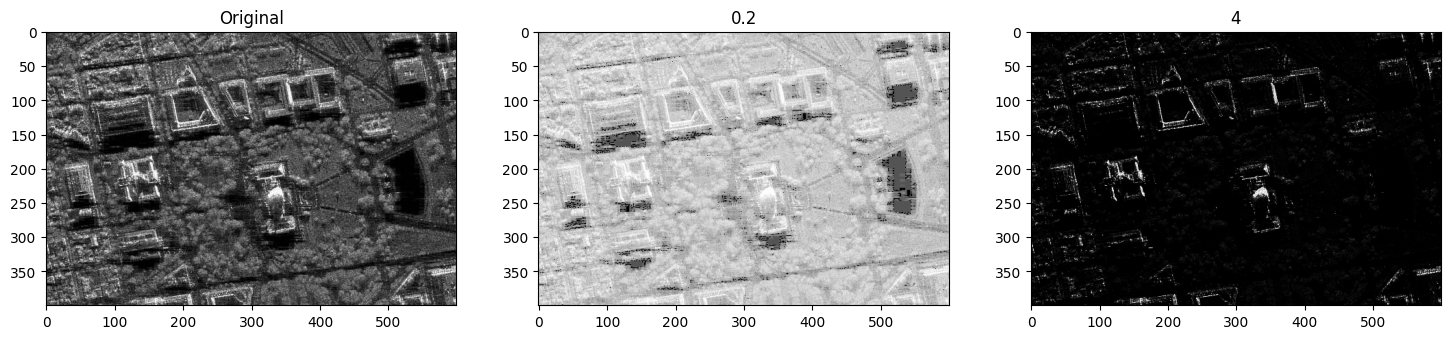

In [19]:
def gamma_correction(image, gamma):
    corrected = np.power(image / 255.0, gamma) * 255
    return corrected.astype(np.uint8)

plt.figure(figsize=(18, 6))
plt.subplot(1, 3, 1);
plt.imshow(gray_image, cmap="gray");
plt.title("Original")
plt.subplot(1, 3, 2);
plt.imshow(gamma_correction(gray_image, 0.2), cmap="gray");
plt.title("0.2")
plt.subplot(1, 3, 3);
plt.imshow(gamma_correction(gray_image, 4), cmap="gray");
plt.title("4")
plt.show()

4. MSE / SSIM

gamma = 0.2: MSE = 14018.05, SSIM = 0.5027


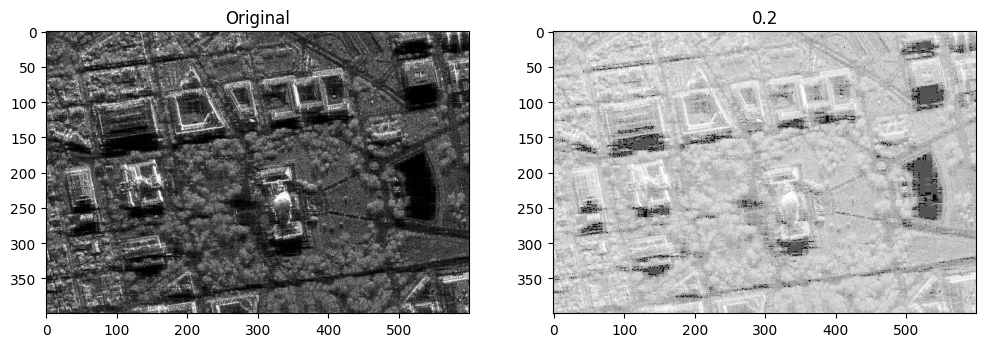

gamma = 4: MSE = 5502.76, SSIM = 0.1046


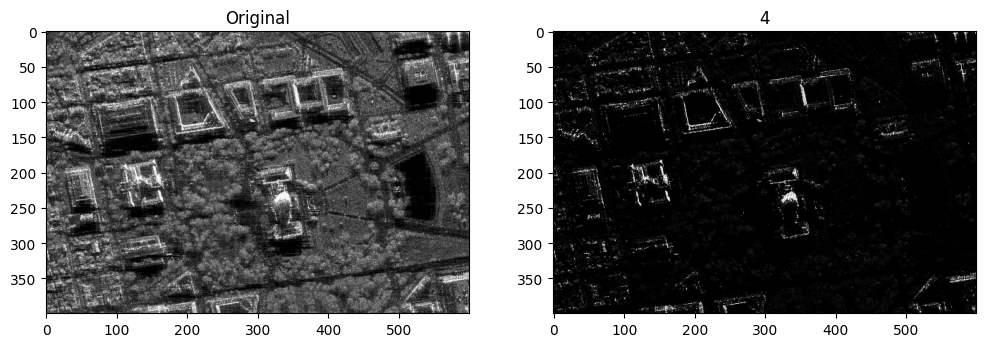

In [22]:
mse_low = mean_squared_error(gray_image, gamma_correction(gray_image, 0.2))
ssim_low = structural_similarity(gray_image, gamma_correction(gray_image, 0.2), data_range=255)
print(f"gamma = 0.2: MSE = {mse_low:.2f}, SSIM = {ssim_low:.4f}")

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1); plt.imshow(gray_image, cmap="gray"); plt.title("Original")
plt.subplot(1, 2, 2); plt.imshow(gamma_correction(gray_image, 0.2), cmap="gray"); plt.title("0.2")
plt.show()


mse_high = mean_squared_error(gray_image, gamma_correction(gray_image, 4))
ssim_high = structural_similarity(gray_image, gamma_correction(gray_image, 4), data_range=255)
print(f"gamma = 4: MSE = {mse_high:.2f}, SSIM = {ssim_high:.4f}")

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1); plt.imshow(gray_image, cmap="gray"); plt.title("Original")
plt.subplot(1, 2, 2); plt.imshow(gamma_correction(gray_image, 4), cmap="gray"); plt.title("4")
plt.show()

5. Statistical correction

original:      mean = 74.94 std = 43.66
eq_gray:       mean = 127.03 std = 74.27
corrected:     mean = 123.12 std = 65.30


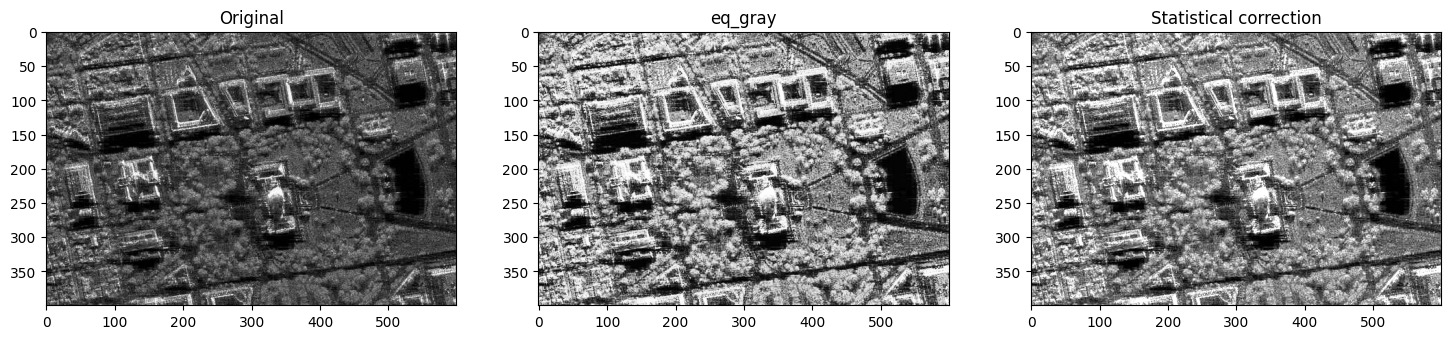

In [34]:
def equalize(image):
    hist, _ = np.histogram(image.flatten(), bins=256, range=(0, 256))
    cdf = hist.cumsum()
    cdf_min = cdf[cdf > 0].min()
    total = image.size
    cdf_norm = (cdf - cdf_min) / (total - cdf_min) * 255
    cdf_norm = np.round(cdf_norm).astype(np.uint8)
    return cdf_norm[image]


eq_gray = equalize(gray_image)

mean_src, std_src = gray_image.mean(), gray_image.std()
mean_ref, std_ref = eq_gray.mean(), eq_gray.std()

stat_corrected = (gray_image - mean_src) * (std_ref / std_src) + mean_ref
stat_corrected = np.clip(stat_corrected, 0, 255).astype(np.uint8)

print("original: mean =", f"{mean_src:.2f}", "std =", f"{std_src:.2f}")
print("eq_gray: mean =", f"{mean_ref:.2f}", "std =", f"{std_ref:.2f}")
print("corrected: mean =", f"{stat_corrected.mean():.2f}", "std =", f"{stat_corrected.std():.2f}")

plt.figure(figsize=(18, 6))
plt.subplot(1, 3, 1); plt.imshow(gray_image, cmap="gray"); plt.title("Original")
plt.subplot(1, 3, 2); plt.imshow(eq_gray, cmap="gray"); plt.title("eq_gray")
plt.subplot(1, 3, 3); plt.imshow(stat_corrected, cmap="gray"); plt.title("Statistical correction")
plt.show()

6. Treshold

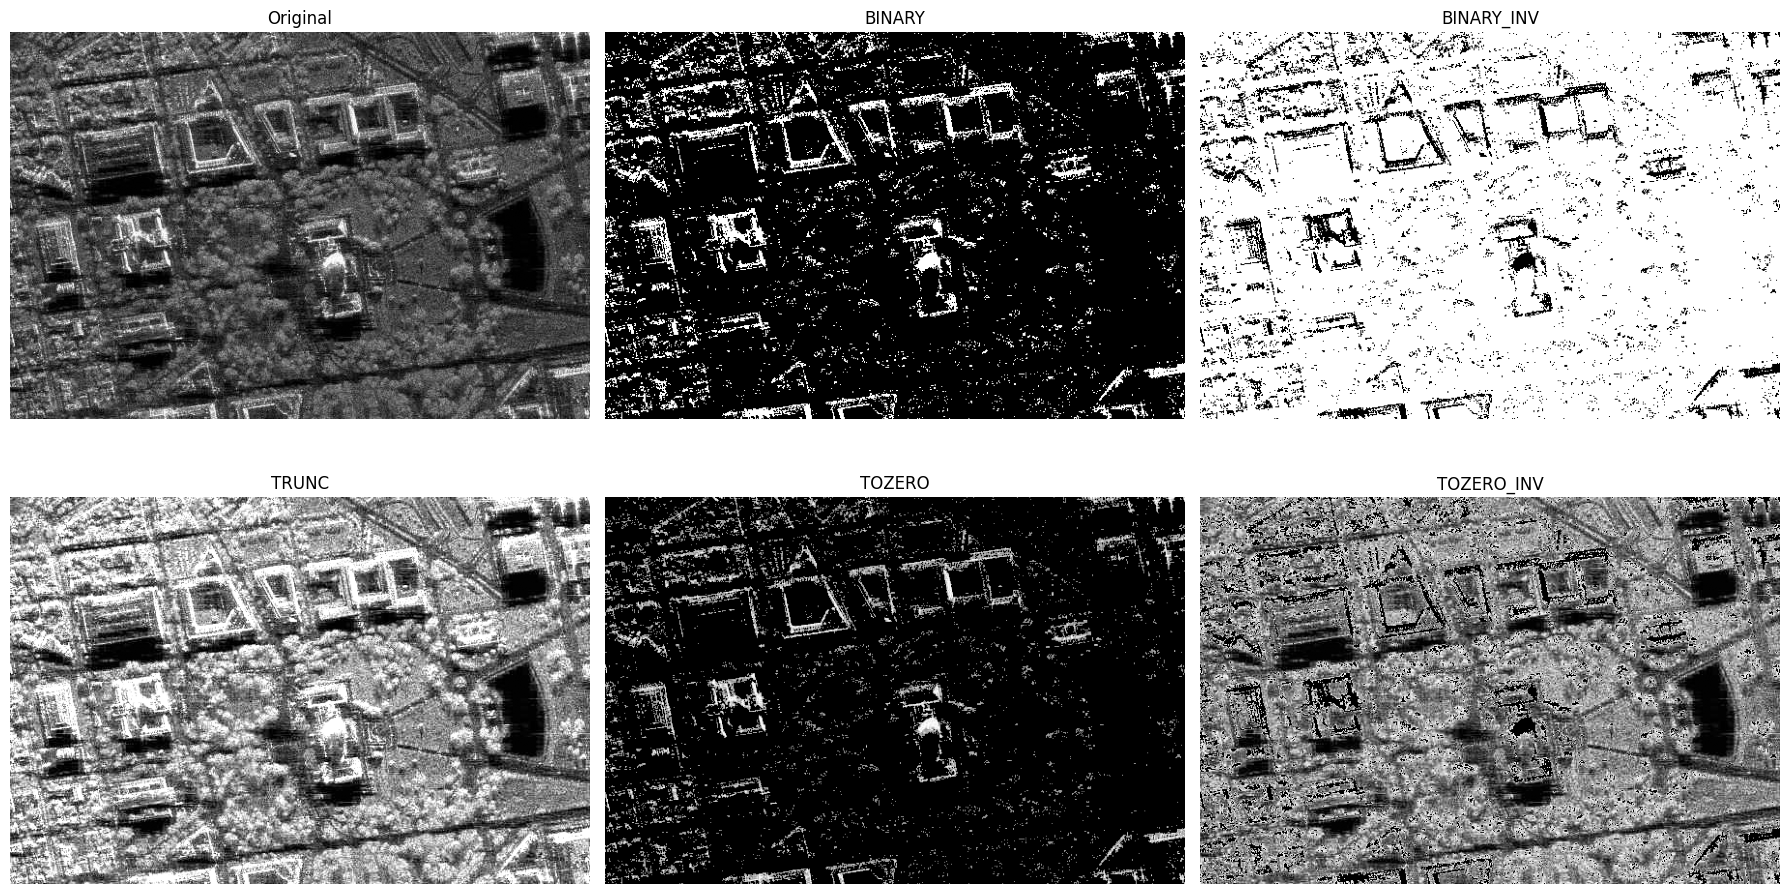

In [36]:
_, th_bin = cv2.threshold(gray_image, 127, 255, cv2.THRESH_BINARY)
_, th_bin_inv = cv2.threshold(gray_image, 127, 255, cv2.THRESH_BINARY_INV)
_, th_trunc = cv2.threshold(gray_image, 127, 255, cv2.THRESH_TRUNC)
_, th_tozero = cv2.threshold(gray_image, 127, 255, cv2.THRESH_TOZERO)
_, th_tozero_inv = cv2.threshold(gray_image, 127, 255, cv2.THRESH_TOZERO_INV)

imgs = [gray_image, th_bin, th_bin_inv, th_trunc, th_tozero, th_tozero_inv]
names = ["Original", "BINARY", "BINARY_INV", "TRUNC", "TOZERO", "TOZERO_INV"]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, im, name in zip(axes.ravel(), imgs, names):
    ax.imshow(im, cmap="gray")
    ax.set_title(name)
    ax.axis("off")
plt.tight_layout()
plt.show()